<a href="https://colab.research.google.com/github/jeyji1949/-BioSeq-Analyzer---Mini-Projet-Biopython/blob/main/HOG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spritan1/yolo-annotated-chestxray-8-object-detection")

print("Path to dataset files:", path)

100%|██████████| 79.2M/79.2M [00:05<00:00, 16.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/spritan1/yolo-annotated-chestxray-8-object-detection/versions/5


In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. حددي الـ Path ديال الصور والـ Labels
# غانستعملو الـ path اللي طلع ليك فـ Screenshot
base_path = "/root/.cache/kagglehub/datasets/spritan1/yolo-annotated-chestxray-8-object-detection/versions/5"
images_dir = os.path.join(base_path, "images")
labels_dir = os.path.join(base_path, "labels")

# 2. لستة باش نجمعو فيها القلوب (X) و النوع (y)
hearts_images = []
labels_list = []

# الصنف (Class) ديال Cardiomegaly فهاد الـ dataset غالبا هو 1
# (تأكدي من ملف classes.txt إيلا كان موجود)
CARDIOMEGALY_ID = 1

# 3. دورة على أول 100 تصويرة (للتجربة فقط)
all_labels = os.listdir(labels_dir)[:100]

for label_file in all_labels:
    with open(os.path.join(labels_dir, label_file), 'r') as f:
        lines = f.readlines()

    for line in lines:
        data = line.split()
        class_id = int(data[0])

        # إيلا لقينا Cardiomegaly
        if class_id == CARDIOMEGALY_ID:
            img_path = os.path.join(images_dir, label_file.replace('.txt', '.jpg'))
            image = cv2.imread(img_path)

            if image is not None:
                h, w, _ = image.shape
                # YOLO format: class x_center y_center width height (normalized 0 to 1)
                x_center, y_center, width, height = map(float, data[1:])

                # تحويل الإحداثيات لـ Pixels
                x1 = int((x_center - width/2) * w)
                y1 = int((y_center - height/2) * h)
                x2 = int((x_center + width/2) * w)
                y2 = int((y_center + height/2) * h)

                # تقطيع القلب (Crop)
                crop_img = image[max(0,y1):min(h,y2), max(0,x1):min(w,x2)]

                # Resize لـ 128x128 باش HOG يخدم مقاد
                crop_img = cv2.resize(crop_img, (128, 128))

                hearts_images.append(crop_img)
                labels_list.append(1) # 1 يعني كاين تضخم

print(f"تم تقطيع {len(hearts_images)} قلب بنجاح!")

# عرض مثال للقلب المقطع
if len(hearts_images) > 0:
    plt.imshow(cv2.cvtColor(hearts_images[0], cv2.COLOR_BGR2RGB))
    plt.title("Example of Cropped Heart")
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kagglehub/datasets/spritan1/yolo-annotated-chestxray-8-object-detection/versions/5/labels'

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# ✅ Correct paths based on actual dataset structure
base_path = "/kaggle/input/yolo-annotated-chestxray-8-object-detection/chestXray8_512"
train_images_dir = os.path.join(base_path, "train", "images")
train_labels_dir = os.path.join(base_path, "train", "labels")

# Quick sanity check
print(f"Train images: {len(os.listdir(train_images_dir))} files")
print(f"Train labels: {len(os.listdir(train_labels_dir))} files")

# Preview first few label filenames
print("\nSample label files:")
for f in os.listdir(train_labels_dir)[:5]:
    print(f"  {f}")

# Preview content of one label file to confirm class IDs
sample_label = os.listdir(train_labels_dir)[0]
print(f"\nContent of '{sample_label}':")
with open(os.path.join(train_labels_dir, sample_label), 'r') as f:
    print(f.read())

Train images: 631 files
Train labels: 631 files

Sample label files:
  00018762_001.txt
  00013670_151.txt
  00012123_001.txt
  00000034_001.txt
  00000013_014.txt

Content of '00018762_001.txt':
2 0.7072222222222226 0.684759267171224 0.08 0.07555555555555557



In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE       = "/kaggle/input/yolo-annotated-chestxray-8-object-detection/chestXray8_512"
TRAIN_IMG  = os.path.join(BASE, "train", "images")
TRAIN_LBL  = os.path.join(BASE, "train", "labels")
VAL_IMG    = os.path.join(BASE, "val",   "images")
VAL_LBL    = os.path.join(BASE, "val",   "labels")

CARDIOMEGALY_ID = 1   # confirm from your label file check
IMG_SIZE        = 64  # resize crops to 64×64 grayscale

# ── Feature extraction ─────────────────────────────────────────────────────────
def extract_hog(image_bgr):
    """
    Convert to grayscale and extract HOG features.
    HOG captures the distribution of gradient orientations (edges/contours),
    which is exactly what differentiates an enlarged heart silhouette from a normal one.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
    features, _ = hog(
        gray,
        orientations=9,          # 9 gradient direction bins (0°–180°)
        pixels_per_cell=(8, 8),  # local cell size
        cells_per_block=(2, 2),  # normalization block size
        visualize=True,
        feature_vector=True
    )
    return features

# ── Dataset builder ────────────────────────────────────────────────────────────
def build_dataset(images_dir, labels_dir, max_samples=None):
    """
    Returns:
        X : HOG feature vectors
        y : 1 = Cardiomegaly, 0 = Normal/Other

    For the Normal class we sample bounding boxes whose class_id != CARDIOMEGALY_ID.
    This avoids using the full image as "normal" (which adds noise) while
    keeping the crop-level comparison fair.
    """
    X, y = [], []
    label_files = os.listdir(labels_dir)
    if max_samples:
        label_files = label_files[:max_samples]

    for lf in label_files:
        img_path = os.path.join(images_dir, lf.replace('.txt', '.jpg'))
        image    = cv2.imread(img_path)
        if image is None:
            continue
        h, w = image.shape[:2]

        with open(os.path.join(labels_dir, lf)) as f:
            lines = f.readlines()

        for line in lines:
            parts    = line.strip().split()
            class_id = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])

            # Convert YOLO normalized coords → pixel coords
            x1 = int((xc - bw/2) * w);  x2 = int((xc + bw/2) * w)
            y1 = int((yc - bh/2) * h);  y2 = int((yc + bh/2) * h)
            crop = image[max(0,y1):min(h,y2), max(0,x1):min(w,x2)]

            if crop.size == 0:
                continue

            features = extract_hog(crop)

            if class_id == CARDIOMEGALY_ID:
                X.append(features); y.append(1)
            else:
                X.append(features); y.append(0)  # other pathologies → "Normal" class

    return np.array(X), np.array(y)

print("Building dataset from training split...")
X, y = build_dataset(TRAIN_IMG, TRAIN_LBL)
print(f"Total samples  : {len(y)}")
print(f"Cardiomegaly (1): {np.sum(y==1)}")
print(f"Other/Normal (0): {np.sum(y==0)}")

Building dataset from training split...
Total samples  : 0
Cardiomegaly (1): 0
Other/Normal (0): 0


In [ ]:
# ── Balance classes via upsampling the minority ────────────────────────────────
def balance_dataset(X, y):
    X0, y0 = X[y==0], y[y==0]
    X1, y1 = X[y==1], y[y==1]

    if len(X0) > len(X1):                        # Cardiomegaly is minority
        X1_up, y1_up = resample(X1, y1, replace=True,
                                n_samples=len(X0), random_state=42)
        return np.vstack([X0, X1_up]), np.hstack([y0, y1_up])
    else:                                        # Other is minority
        X0_up, y0_up = resample(X0, y0, replace=True,
                                n_samples=len(X1), random_state=42)
        return np.vstack([X1, X0_up]), np.hstack([y1, y0_up])

X_bal, y_bal = balance_dataset(X, y)
print(f"\nAfter balancing → Class 0: {np.sum(y_bal==0)} | Class 1: {np.sum(y_bal==1)}")

# ── Train / Evaluate ───────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

svm = LinearSVC(C=1.0, max_iter=5000)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred,
                             target_names=["Normal/Other", "Cardiomegaly"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Cardiomegaly"])
disp.plot(cmap="Blues")
plt.title("HOG + SVM — Confusion Matrix")
plt.tight_layout()
plt.savefig("hog_svm_confusion.png", dpi=150)
plt.show()

InvalidParameterError: The 'n_samples' parameter of resample must be an int in the range [1, inf) or None. Got 0 instead.

In [ ]:
import os

BASE      = "/kaggle/input/yolo-annotated-chestxray-8-object-detection/chestXray8_512"
TRAIN_IMG = os.path.join(BASE, "train", "images")
TRAIN_LBL = os.path.join(BASE, "train", "labels")

# ── Step 1: Check folders exist ────────────────────────────────────────────────
print("Images dir exists:", os.path.exists(TRAIN_IMG))
print("Labels dir exists:", os.path.exists(TRAIN_LBL))

# ── Step 2: Count files ────────────────────────────────────────────────────────
img_files = os.listdir(TRAIN_IMG)
lbl_files = os.listdir(TRAIN_LBL)
print(f"\nTotal image files : {len(img_files)}")
print(f"Total label files : {len(lbl_files)}")

# ── Step 3: Check actual file extensions ──────────────────────────────────────
img_exts = set(os.path.splitext(f)[1] for f in img_files)
print(f"\nImage extensions found: {img_exts}")   # .jpg? .png? .jpeg?

# ── Step 4: Preview first label file content ──────────────────────────────────
sample_lbl = lbl_files[0]
print(f"\nSample label file: {sample_lbl}")
with open(os.path.join(TRAIN_LBL, sample_lbl)) as f:
    content = f.read()
print(f"Content:\n{content}")

# ── Step 5: Check if the matching image actually exists ────────────────────────
for ext in ['.jpg', '.png', '.jpeg']:
    candidate = os.path.join(TRAIN_IMG, sample_lbl.replace('.txt', ext))
    print(f"Looking for {candidate} → exists: {os.path.exists(candidate)}")

Images dir exists: True
Labels dir exists: True

Total image files : 631
Total label files : 631

Image extensions found: {'.png'}

Sample label file: 00018762_001.txt
Content:
2 0.7072222222222226 0.684759267171224 0.08 0.07555555555555557

Looking for /kaggle/input/yolo-annotated-chestxray-8-object-detection/chestXray8_512/train/images/00018762_001.jpg → exists: False
Looking for /kaggle/input/yolo-annotated-chestxray-8-object-detection/chestXray8_512/train/images/00018762_001.png → exists: True
Looking for /kaggle/input/yolo-annotated-chestxray-8-object-detection/chestXray8_512/train/images/00018762_001.jpeg → exists: False


In [ ]:
# ── Step 1: Check class distribution across ALL label files ───────────────────
from collections import Counter

BASE      = "/kaggle/input/yolo-annotated-chestxray-8-object-detection/chestXray8_512"
TRAIN_LBL = os.path.join(BASE, "train", "labels")

class_counter = Counter()

for lf in os.listdir(TRAIN_LBL):
    with open(os.path.join(TRAIN_LBL, lf)) as f:
        for line in f.readlines():
            parts = line.strip().split()
            if parts:
                class_counter[int(parts[0])] += 1

print("Class ID → Count across all training labels:")
for class_id, count in sorted(class_counter.items()):
    print(f"  Class {class_id} : {count} annotations")

Class ID → Count across all training labels:
  Class 0 : 120 annotations
  Class 1 : 124 annotations
  Class 2 : 128 annotations
  Class 3 : 144 annotations
  Class 4 : 78 annotations


In [ ]:
# ── Check for a classes.txt or any metadata file in the dataset ───────────────
import os

BASE = "/kaggle/input/yolo-annotated-chestxray-8-object-detection/chestXray8_512"

# Search for any file that might contain class names
for root, dirs, files in os.walk(BASE):
    for f in files:
        if any(keyword in f.lower() for keyword in ['class', 'label', 'name', '.yaml', '.csv', '.txt']):
            full_path = os.path.join(root, f)
            print(f"\nFound: {full_path}")
            # Print first 20 lines
            try:
                with open(full_path) as fp:
                    lines = fp.readlines()[:20]
                    for line in lines:
                        print(f"  {line.rstrip()}")
            except:
                print("  (binary or unreadable)")


Found: /kaggle/input/yolo-annotated-chestxray-8-object-detection/chestXray8_512/chestxray8.csv
  ,Image Index,Finding Label,Bbox [x,y,w,h],Width,Height
  0,00013118_008.png,Atelectasis,225.084745762712,547.019216763771,86.7796610169491,79.1864406779661,1024.0,1024.0
  1,00014716_007.png,Atelectasis,686.101694915254,131.543498411017,185.491525423729,313.491525423729,1024.0,1024.0
  2,00029817_009.png,Atelectasis,221.830508474576,317.053115068856,155.118644067797,216.949152542373,1024.0,1024.0
  3,00014687_001.png,Atelectasis,726.237288135593,494.951420153602,141.016949152542,55.3220338983051,1024.0,1024.0
  4,00017877_001.png,Atelectasis,660.067796610169,569.78078654661,200.677966101695,78.1016949152542,1024.0,1024.0
  5,00003148_004.png,Atelectasis,596.067796610169,505.78078654661,56.4067796610169,180.067796610169,1024.0,1024.0
  6,00012515_002.png,Atelectasis,289.084745762712,638.137860831568,83.5254237288136,56.4067796610169,1024.0,1024.0
  7,00022098_006.png,Atelectasis,494.1016949

Building dataset...
Skipped (not found): 0
Total      : 594
Cardio (1) : 124
Other  (0) : 470

Balanced → Class 0: 470 | Class 1: 470

── Classification Report ──────────────────────
              precision    recall  f1-score   support

       Other       0.98      0.90      0.94        94
Cardiomegaly       0.91      0.98      0.94        94

    accuracy                           0.94       188
   macro avg       0.94      0.94      0.94       188
weighted avg       0.94      0.94      0.94       188



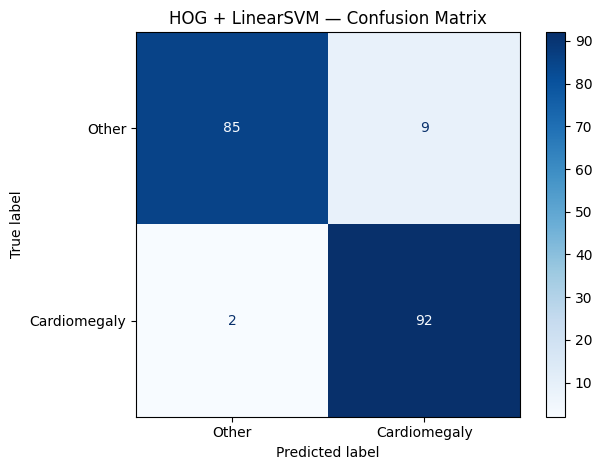

In [ ]:
import cv2, os
import numpy as np
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
import matplotlib.pyplot as plt

BASE           = "/kaggle/input/yolo-annotated-chestxray-8-object-detection/chestXray8_512"
TRAIN_IMG      = os.path.join(BASE, "train", "images")
TRAIN_LBL      = os.path.join(BASE, "train", "labels")
CARDIOMEGALY_ID = 1
IMG_SIZE        = 64

# ── HOG feature extraction ─────────────────────────────────────────────────────
def extract_hog(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
    features, _ = hog(gray, orientations=9, pixels_per_cell=(8,8),
                      cells_per_block=(2,2), visualize=True, feature_vector=True)
    return features

# ── Dataset builder ────────────────────────────────────────────────────────────
def build_dataset(images_dir, labels_dir):
    X, y, skipped = [], [], 0
    for lf in os.listdir(labels_dir):
        img_path = os.path.join(images_dir, lf.replace('.txt', '.png'))  # ✅ .png fix
        image    = cv2.imread(img_path)
        if image is None:
            skipped += 1
            continue
        h, w = image.shape[:2]
        with open(os.path.join(labels_dir, lf)) as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            class_id        = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])
            x1 = max(0, int((xc - bw/2) * w));  x2 = min(w, int((xc + bw/2) * w))
            y1 = max(0, int((yc - bh/2) * h));  y2 = min(h, int((yc + bh/2) * h))
            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            X.append(extract_hog(crop))
            y.append(1 if class_id == CARDIOMEGALY_ID else 0)
    print(f"Skipped (not found): {skipped}")
    return np.array(X), np.array(y)

print("Building dataset...")
X, y = build_dataset(TRAIN_IMG, TRAIN_LBL)
print(f"Total      : {len(y)}")
print(f"Cardio (1) : {np.sum(y==1)}")
print(f"Other  (0) : {np.sum(y==0)}")

# ── Balance ────────────────────────────────────────────────────────────────────
def balance(X, y):
    X0, y0 = X[y==0], y[y==0]
    X1, y1 = X[y==1], y[y==1]
    if len(X0) > len(X1):
        X1, y1 = resample(X1, y1, replace=True, n_samples=len(X0), random_state=42)
    else:
        X0, y0 = resample(X0, y0, replace=True, n_samples=len(X1), random_state=42)
    return np.vstack([X0, X1]), np.hstack([y0, y1])

X_bal, y_bal = balance(X, y)
print(f"\nBalanced → Class 0: {np.sum(y_bal==0)} | Class 1: {np.sum(y_bal==1)}")

# ── Train & Evaluate ───────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42)

svm = LinearSVC(C=1.0, max_iter=5000)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print("\n── Classification Report ──────────────────────")
print(classification_report(y_test, y_pred, target_names=["Other", "Cardiomegaly"]))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Other", "Cardiomegaly"])
disp.plot(cmap="Blues")
plt.title("HOG + LinearSVM — Confusion Matrix")
plt.tight_layout()
plt.savefig("hog_svm_confusion.png", dpi=150)
plt.show()